Prédiction de l'iC-Apex par deep learning

Covariables attendues (rasters .tif au même SCR et résolution) :
  - alt        : altitude (m)
  - ru         : réserve utile (classes)
  - intégration de la CWB en tant que série temporelle (WIP)
 
Variable cible :
  - probabilité de non-stress hydrique : valeur continue

Approche visant une prédiction de la probabilité de non-stress hydrique (classification en deux classes : 0 stress, 1 non-stress), utilisant une loss BCE. Prédit la probabilité que l'observation appartienne à la classe "croissance active". Intégration du MC dropout pour le calcul de l'incertitude associée. Intégration des KFold pour le split.
 
Auteur : Thomas JUILLAC

# 0. IMPORTS

In [78]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import glob
import os
from tqdm import tqdm
import verde as vd

# Geospatial libraries
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import box

# Machine Learning
import torch
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


# 1. LOAD APEX-VIGNE DATASET

1.1 LOAD DATASET

In [79]:
# Load the apex-vigne dataset
df = pd.read_csv('data/data_apex.csv', encoding='latin1', low_memory=False)

print(f"📊 Dataset shape: {df.shape[0]:,} observations × {df.shape[1]} columns")
print(f"\n🔤 Available columns:\n{df.columns.tolist()[:15]}...")

# Display first few rows
df.head(3)

📊 Dataset shape: 46,403 observations × 20 columns

🔤 Available columns:
['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude']...


,id_session,date_creation,date_maj,date_session,apex0,apex1,apex2,id_observateur,id_parcelle,id_stade,commentaire,device_hardware,device_software,longitude,latitude,location,en_parcelle,est_archivee,raison_archive,app_version
0,00020b39-e765-4337-999a-63e1f59aca46,2025-08-19 13:43:38,2025-08-19 13:43:38,2025-07-24,4,37,9,4e5e6f16-d26c-428e-a387-007533fa7be9,5843944e-d9d2-48cc-95c8-8d639807b031,NaN,NaN,iPhone,iOS 18.5,6.132792,45.550099,NaN,1.0,0,NaN,6.2.0
1,00041c61510442e5a64fb3af8ce11e24,2024-05-02 12:16:41,2025-04-18 08:46:16,2024-05-02,35,15,2,70c659af882b42ffb6b9415995434669,2f635c3720504254aebd2687712b0c8b,st-H-57-57,NaN,iPhone,iOS 17.4.1,3.544615,43.533837,NaN,1.0,0,NaN,NaN
2,0007ba68-e4f1-3fbd-82a9-336c7718bb2a,2020-06-25 04:27:02,2025-04-18 08:45:29,2019-07-10,13,31,6,edb6d513-eb76-4ad0-ae8a-0be7770048eb,5241d050-de2c-d5e5-a9f7-59f03c2e12ea,NaN,NaN,samsung SM-A715F,Android 11,NaN,NaN,NaN,0.0,0,NaN,NaN


1.2 FILTER ON DATE

In [80]:
#Filtrer les observations par date

# Paramètres à modifier
date_debut = "2025-07-14"
date_fin   = "2025-07-20"

# Filtrage temporel
df['date_session'] = pd.to_datetime(df['date_session'], errors='coerce')
df_filtered = df[(df['date_session'] >= date_debut) & (df['date_session'] <= date_fin)]

print(f"📅 Période sélectionnée : {date_debut} → {date_fin}")
print(f"📊 Observations totales  : {len(df):,}")
print(f"📊 Après filtrage        : {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}%)")
print(f"\n📋 Période couverte par les données filtrées :")
print(f"   De : {df_filtered['date_session'].min().date()}")
print(f"   À  : {df_filtered['date_session'].max().date()}")

📅 Période sélectionnée : 2025-07-14 → 2025-07-20
📊 Observations totales  : 46,403
📊 Après filtrage        : 1,257 (2.7%)

📋 Période couverte par les données filtrées :
   De : 2025-07-14
   À  : 2025-07-20


1.3 FILTER ON LOCATION

In [81]:
# Conversion en objet spatial
data_sf = (df_filtered
    .assign(
        longitude = pd.to_numeric(df['longitude'].replace("NULL", pd.NA), errors='coerce'),
        latitude  = pd.to_numeric(df['latitude'].replace("NULL", pd.NA),  errors='coerce')
    )
    .dropna(subset=['longitude', 'latitude'])
    .pipe(lambda d: gpd.GeoDataFrame(
        d,
        geometry=gpd.points_from_xy(d['longitude'], d['latitude']),
        crs="EPSG:4326"
    ))
)

In [82]:
# Filtrer les observations dans la zone d'étude
study_zone = gpd.read_file("data/study_zone.gpkg")
data_sf_proj = data_sf.to_crs(study_zone.crs)
data_zone = data_sf_proj[data_sf_proj.within(study_zone.union_all())]

data_zone = data_sf_proj[data_sf_proj.within(study_zone.union_all())].copy()

# Calcul de l'iG-APEX
data_zone['ig_apex'] = (data_zone['apex0'] + 0.5 * data_zone['apex1']) / (
    data_zone['apex0'] + data_zone['apex1'] + data_zone['apex2']
)

# ============================================================
# ⚙️ CONFIGURATION
# ============================================================
ALT_MAX           = 800   # mètres — cellules au dessus exclues
IG_APEX_THRESHOLD = 0.5   # >= seuil → présence (1), < seuil → absence (0)
ru_classes        = [1, 2, 3, 4, 5, 9]
n_onehot          = len(ru_classes)  # 6
# ============================================================

print(f"📊 Avant filtre zone : {len(data_sf_proj):,} observations")
print(f"📊 Après filtre zone : {len(data_zone):,} observations")
print(f"   Soit {len(data_zone)/len(data_sf_proj)*100:.1f}% des observations retenues")

📊 Avant filtre zone : 1,247 observations
📊 Après filtre zone : 827 observations
   Soit 66.3% des observations retenues


# 2. DATA VISUALISATION (ALREADY DONE IN R)

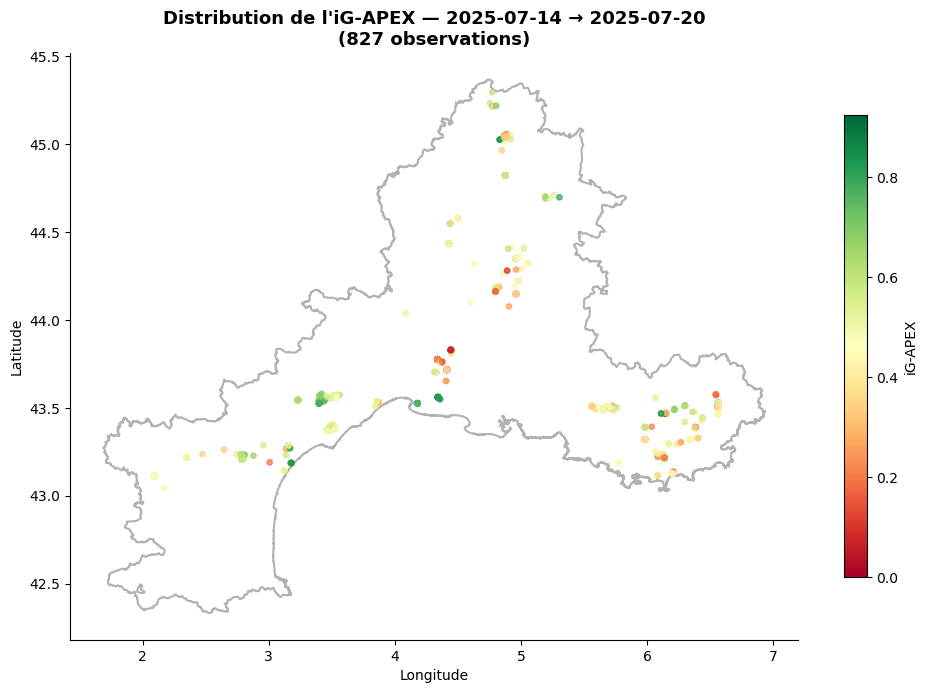

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Reprojection en WGS84 pour affichage cohérent
study_zone_wgs = study_zone.to_crs("EPSG:4326")
data_zone_wgs  = data_zone.to_crs("EPSG:4326")

# Contour de la zone d'étude
study_zone_wgs.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.3
)

# Points colorés par iG-APEX
data_zone_wgs.plot(
    ax=ax,
    column='ig_apex',
    cmap='RdYlGn',
    markersize=15,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'iG-APEX', 'shrink': 0.6}
)

ax.set_title(
    f"Distribution de l'iG-APEX — {date_debut} → {date_fin}\n"
    f"({len(data_zone_wgs):,} observations)",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [84]:
print(data_zone.columns.tolist())

['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude', 'location', 'en_parcelle', 'est_archivee', 'raison_archive', 'app_version', 'geometry', 'ig_apex']


# 3. LOAD STUDY ZONE (GRID)

In [85]:
grid = gpd.read_file("data/study_zone_grid.gpkg")
grid.head()

,id,left,top,right,bottom,row_index,col_index,geometry
0,233,593491.216894,6.243619e+06,594491.216894,6.242619e+06,232,0,"MULTIPOLYGON (((594147.893 6242691.759, 594182..."
1,234,593491.216894,6.242619e+06,594491.216894,6.241619e+06,233,0,"MULTIPOLYGON (((594077.807 6241631.64, 594057...."
2,235,593491.216894,6.241619e+06,594491.216894,6.240619e+06,234,0,"MULTIPOLYGON (((594487.234 6240783.55, 594463...."
3,236,593491.216894,6.240619e+06,594491.216894,6.239619e+06,235,0,"MULTIPOLYGON (((594113.921 6239641.903, 594131..."
4,237,593491.216894,6.239619e+06,594491.216894,6.238619e+06,236,0,"MULTIPOLYGON (((594472.355 6239234.844, 594419..."


# 4. RASTERS

In [86]:
# Lister tous les rasters dans les sous-dossiers
subfolders = ['alt', 'ru']  # CWB géré séparément
raster_files = []
for sub in subfolders:
    files = sorted(glob.glob(f'data/cov/rasters/{sub}/*.tif'))
    raster_files.extend(files)

print(f"📂 {len(raster_files)} rasters trouvés :\n")
for f in raster_files:
    with rasterio.open(f) as src:
        res = abs(src.transform[0])
        print(f"   {f}")
        print(f"      Dimensions : {src.width} × {src.height} pixels")
        print(f"      Résolution : {res:.0f} m\n")

📂 2 rasters trouvés :

   data/cov/rasters/alt\altitude_study_zone.tif
      Dimensions : 424 × 337 pixels
      Résolution : 1000 m

   data/cov/rasters/ru\ru_raster.tif
      Dimensions : 425 × 336 pixels
      Résolution : 1000 m



# 5. VISUALISATION OF COVARIABLES

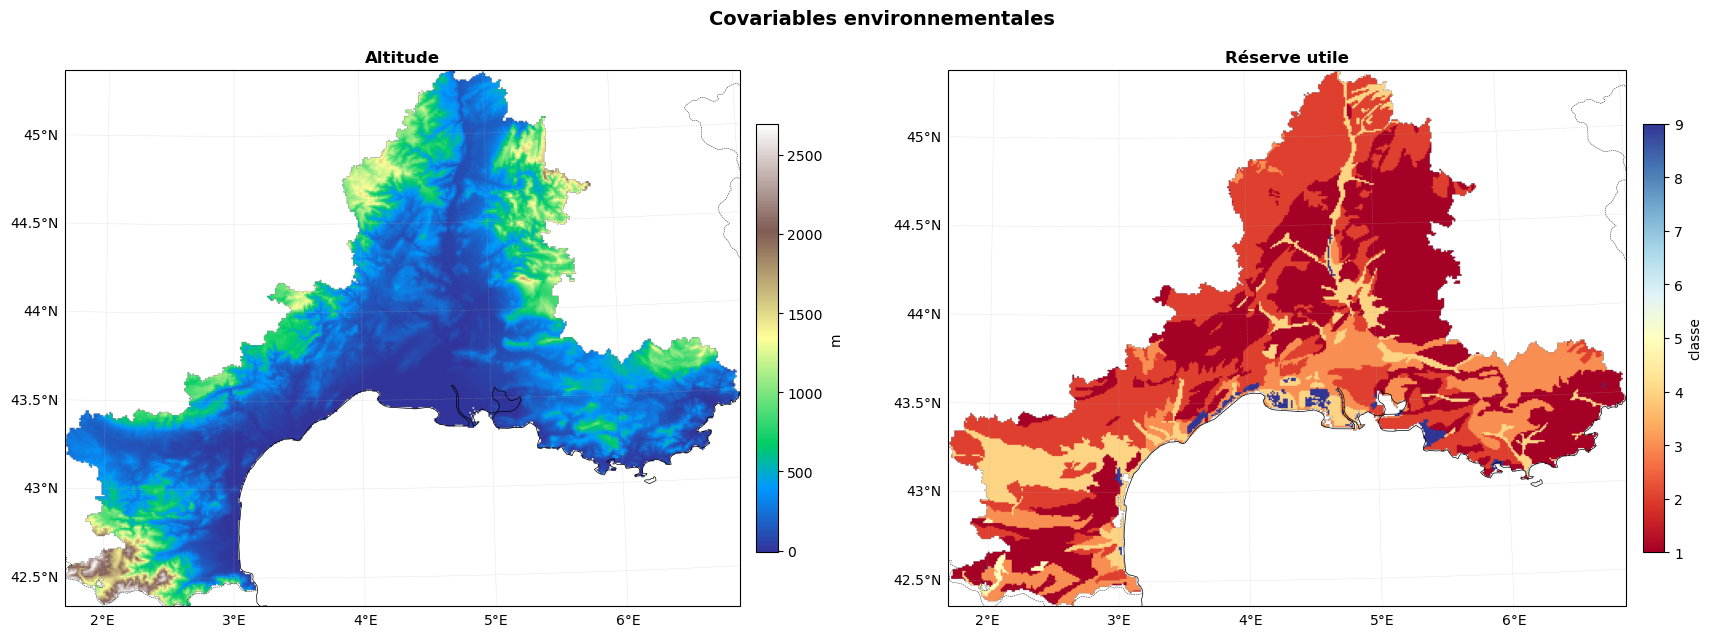

In [87]:
variables_to_plot = [
    ('data/cov/rasters/alt/altitude_study_zone.tif',          'Altitude',      'm',     'terrain'),
    ('data/cov/rasters/ru/ru_raster.tif',                     'Réserve utile', 'classe','RdYlBu')
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                         subplot_kw={'projection': ccrs.epsg(2154)})

for ax, (filepath, title, unit, cmap) in zip(axes, variables_to_plot):
    with rasterio.open(filepath) as src:
        data   = src.read(1).astype(np.float32)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        nodata = src.nodata

        if nodata is not None:
            data = np.ma.masked_where((data == nodata) | ~np.isfinite(data), data)
        else:
            data = np.ma.masked_where(
                (data <= -9999) | (data == 0) | ~np.isfinite(data), data
            )

    ax.set_facecolor('none')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle='--')

    im = ax.imshow(data, extent=extent, origin='upper', cmap=cmap,
                   transform=ccrs.epsg(2154))

    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(unit, fontsize=10)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Covariables environnementales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [88]:
# CWB cumulée moyenne sur la période d'observation
cwb_wide = pd.read_csv('data/cov/cwb/cwb2025_cumsum.csv')  # ✅ bon fichier
date_cols = [c for c in cwb_wide.columns if c not in ('cell', 'latitude', 'longitude')]

date_cols_session = [
    c for c in date_cols
    if pd.Timestamp(date_debut) <= pd.Timestamp(c) <= pd.Timestamp(date_fin)
]
cwb_wide['cwb_mean_session'] = cwb_wide[date_cols_session].mean(axis=1)

# Reprojection en Lambert 93
cwb_gdf_viz = gpd.GeoDataFrame(
    cwb_wide[['cell', 'latitude', 'longitude', 'cwb_mean_session']],
    geometry=gpd.points_from_xy(cwb_wide['longitude'], cwb_wide['latitude']),
    crs="EPSG:4326"
).to_crs("EPSG:2154")

pts_x = cwb_gdf_viz.geometry.x.values
pts_y = cwb_gdf_viz.geometry.y.values
pts_v = cwb_gdf_viz['cwb_mean_session'].values

print(f"📂 CWB cumulée chargée : {cwb_wide.shape}")
print(f"   Mailles SAFRAN : {len(cwb_wide):,}")
print(f"   Période        : {date_cols[0]} → {date_cols[-1]}")
print(f"   Nb jours       : {len(date_cols)}")
print(f"\n📊 Statistiques au dernier jour ({date_cols[-1]}) :")
print(f"   min  : {cwb_wide[date_cols[-1]].min():.1f} mm")
print(f"   max  : {cwb_wide[date_cols[-1]].max():.1f} mm")
print(f"   mean : {cwb_wide[date_cols[-1]].mean():.1f} mm")

📂 CWB cumulée chargée : (144075, 247)
   Mailles SAFRAN : 144,075
   Période        : 2025-01-01 → 2025-08-31
   Nb jours       : 243

📊 Statistiques au dernier jour (2025-08-31) :
   min  : -512.8 mm
   max  : 586.2 mm
   mean : -192.9 mm


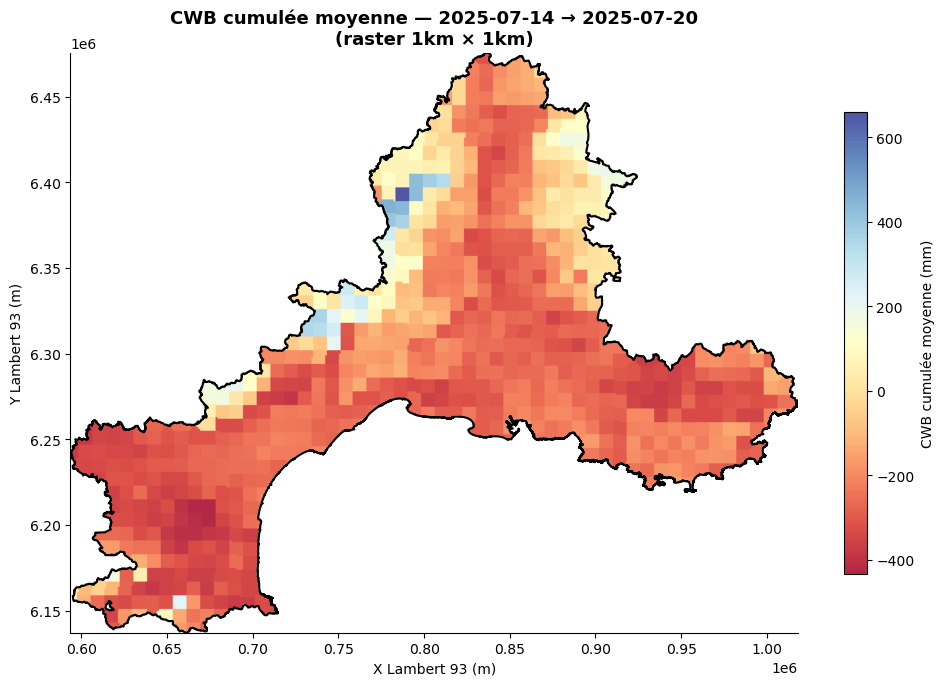

In [89]:
from scipy.interpolate import griddata
# ------------------------------------------------------------------ #
# Grille raster 1km × 1km - CORRECTION DE L'AXE Y (Du Nord au Sud)
# ------------------------------------------------------------------ #
study_proj   = study_zone.to_crs("EPSG:2154")
bounds       = study_proj.total_bounds  # [minx, miny, maxx, maxy]
resolution   = 1000  # 1km en mètres

grid_x = np.arange(bounds[0], bounds[2], resolution)
# On force Y à aller du Nord (maxy) vers le Sud (miny) en mettant un pas négatif
grid_y = np.arange(bounds[3], bounds[1], -resolution) 
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)

# ------------------------------------------------------------------ #
# Interpolation 
# ------------------------------------------------------------------ #
grid_cwb = griddata(
    points = np.column_stack([pts_x, pts_y]),
    values = pts_v,
    xi     = (grid_xx, grid_yy),
    method = 'nearest'
)

# ------------------------------------------------------------------ #
# Masque zone d'étude (Plus besoin de flipper la matrice ensuite)
# ------------------------------------------------------------------ #
from rasterio.transform import from_origin
from rasterio.features import geometry_mask

# from_origin attend le coin HAUT-GAUCHE (minx, maxy)
transform = from_origin(bounds[0], bounds[3], resolution, resolution)

study_mask = geometry_mask(
    [geom.__geo_interface__ for geom in study_proj.geometry],
    transform = transform,
    invert    = True,
    out_shape = grid_cwb.shape
)

grid_cwb_masked = np.where(study_mask, grid_cwb, np.nan)

# ------------------------------------------------------------------ #
# Carte
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

im = ax.imshow(
    grid_cwb_masked,  # On affiche directement la matrice
    extent  = [bounds[0], bounds[2], bounds[1], bounds[3]],
    origin  = 'upper',  # 'upper' car l'index 0 est maintenant bien le Nord (maxy)
    cmap    = 'RdYlBu',
    alpha   = 0.85,
    aspect  = 'equal'
)

# Contour zone d'étude par-dessus
study_proj.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

plt.colorbar(im, ax=ax, label='CWB cumulée moyenne (mm)', shrink=0.6)
ax.set_title(
    f"CWB cumulée moyenne — {date_debut} → {date_fin}\n(raster 1km × 1km)",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('X Lambert 93 (m)')
ax.set_ylabel('Y Lambert 93 (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 6. PREPARE TRAINING DATA

6.1 RASTER PROPERTIES

In [90]:
# Get raster properties from the first raster
with rasterio.open(raster_files[0]) as src:
    raster_resolution = abs(src.transform[0])
    raster_transform  = src.transform
    raster_crs        = src.crs

print(f"📐 Résolution : {raster_resolution:.0f} m")
print(f"🌐 SCR : {raster_crs}")
print(f"📁 Nombre de variables : {len(raster_files)}")
print(f"\n📋 Variables :")
for i, f in enumerate(raster_files, 1):
    print(f"   {i:2d}. {os.path.basename(f)}")

📐 Résolution : 1000 m
🌐 SCR : EPSG:2154
📁 Nombre de variables : 2

📋 Variables :
    1. altitude_study_zone.tif
    2. ru_raster.tif


In [91]:
# CWB table properties
print(f"📐 Résolution temporelle : journalière (cumul depuis le 01/01)")
print(f"🌐 SCR : WGS84 (EPSG:4326) — lat/lon SAFRAN")
print(f"📁 Fichier : data/cov/cwb/cwb2025_cumsum.csv")
print(f"\n📋 Propriétés :")
print(f"   Mailles SAFRAN  : {len(cwb_wide):,}")
print(f"   Période         : {date_cols[0]} → {date_cols[-1]}")
print(f"   Nb jours        : {len(date_cols)}")
print(f"   Résolution spatiale : ~1 km")
print(f"\n📈 Statistiques CWB cumulée au {date_cols[-1]} :")
print(f"   min  : {cwb_wide[date_cols[-1]].min():.1f} mm")
print(f"   max  : {cwb_wide[date_cols[-1]].max():.1f} mm")
print(f"   mean : {cwb_wide[date_cols[-1]].mean():.1f} mm")
print(f"   std  : {cwb_wide[date_cols[-1]].std():.1f} mm")
print(f"\n⚠️  Valeurs manquantes : {cwb_wide[date_cols].isna().sum().sum():,} / "
      f"{len(cwb_wide) * len(date_cols):,} "
      f"({100 * cwb_wide[date_cols].isna().mean().mean():.1f}%)")

📐 Résolution temporelle : journalière (cumul depuis le 01/01)
🌐 SCR : WGS84 (EPSG:4326) — lat/lon SAFRAN
📁 Fichier : data/cov/cwb/cwb2025_cumsum.csv

📋 Propriétés :
   Mailles SAFRAN  : 144,075
   Période         : 2025-01-01 → 2025-08-31
   Nb jours        : 243
   Résolution spatiale : ~8 km (mailles SAFRAN)

📈 Statistiques CWB cumulée au 2025-08-31 :
   min  : -512.8 mm
   max  : 586.2 mm
   mean : -192.9 mm
   std  : 179.9 mm

⚠️  Valeurs manquantes : 0 / 35,010,225 (0.0%)


6.2 iG-APEX calculation

In [92]:
# Calcul de l'iG-APEX
data_zone = data_zone.copy()
data_zone['date_session'] = pd.to_datetime(data_zone['date_session']).dt.date
data_zone['ig_apex'] = (data_zone['apex0'] + data_zone['apex1'] * 0.5) / \
                       (data_zone['apex0'] + data_zone['apex1'] + data_zone['apex2'])

print(f"📍 Observations brutes      : {len(df):,}")
print(f"📍 Après nettoyage spatial  : {len(data_sf):,}")
print(f"📍 Dans la zone d'étude     : {len(data_zone):,}")
print(f"\n📋 Aperçu iG-APEX :")
print(data_zone['ig_apex'].describe().round(3))

📍 Observations brutes      : 46,403
📍 Après nettoyage spatial  : 1,247
📍 Dans la zone d'étude     : 827

📋 Aperçu iG-APEX :
count    827.000
mean       0.466
std        0.184
min        0.000
25%        0.350
50%        0.481
75%        0.570
max        0.924
Name: ig_apex, dtype: float64


6.3 CREATION OF TENSORS

In [93]:
# Coordonnées des centroïdes de la grille en Lambert
grid_proj  = grid.to_crs("EPSG:2154")
centroids  = [(geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry]
num_cells  = len(grid_proj)

# On exclut les CWB de raster_files — elles sont remplacées par le CSV dynamique
rasters_without_cwb = [f for f in raster_files if 'cwb' not in f.lower()]
num_variables = len(rasters_without_cwb)

print(f"📍 Nombre de cellules   : {num_cells:,}")
print(f"📁 Nombre de variables  : {num_variables} (alt + ru uniquement)")

# Tenseur X — valeurs environnementales (alt + ru)
X_tensor = torch.zeros((num_cells, num_variables), dtype=torch.float32)
print("\n🌡️ Extraction des valeurs des covariables...")
for var_idx, filepath in enumerate(tqdm(rasters_without_cwb, desc="Processing rasters")):
    with rasterio.open(filepath) as src:
        nodata = src.nodata
        values = np.array([val[0] for val in src.sample(centroids)], dtype=np.float32)
        if nodata is not None:
            values[values == nodata] = np.nan
        X_tensor[:, var_idx] = torch.tensor(values, dtype=torch.float32)

# One-hot RU
ru_idx    = next(i for i, f in enumerate(rasters_without_cwb) if 'ru' in f.lower())
ru_values = X_tensor[:, ru_idx].numpy()
ru_classes = [1, 2, 3, 4, 5, 9]
ru_onehot  = np.zeros((num_cells, len(ru_classes)), dtype=np.float32)
for j, cls in enumerate(ru_classes):
    ru_onehot[:, j] = (ru_values == cls).astype(np.float32)

X_np_without_ru = np.delete(X_tensor.numpy(), ru_idx, axis=1)
X_tensor = torch.tensor(
    np.concatenate([X_np_without_ru, ru_onehot], axis=1),
    dtype=torch.float32
)

# Masque altitude
alt_idx    = next(i for i, f in enumerate(rasters_without_cwb) if 'alt' in f.lower())
alt_values = X_tensor[:, alt_idx].numpy()  # avant suppression ru — recalculer si nécessaire
highalt_mask = torch.tensor(alt_values > ALT_MAX, dtype=torch.bool)

print(f"\n✅ Tenseur X créé (sans CWB — sera ajoutée dynamiquement) : {X_tensor.shape}")
print(f"🏔️  Cellules > {ALT_MAX}m exclues : {highalt_mask.sum().item():,} / {num_cells:,}")

📍 Nombre de cellules   : 50,998
📁 Nombre de variables  : 2 (alt + ru uniquement)

🌡️ Extraction des valeurs des covariables...


Processing rasters: 100%|████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.24it/s]


✅ Tenseur X créé (sans CWB — sera ajoutée dynamiquement) : torch.Size([50998, 7])
🏔️  Cellules > 800m exclues : 7,913 / 50,998


In [94]:
# Colonnes date disponibles
date_cols = [c for c in cwb_wide.columns if c not in ('cell', 'latitude', 'longitude')]
print(f"📂 CWB wide chargé : {cwb_wide.shape}")
print(f"   Période : {date_cols[0]} → {date_cols[-1]}")

# 2. Jointure spatiale mailles SAFRAN → cellules de grille
cwb_gdf = gpd.GeoDataFrame(
    cwb_wide,
    geometry=gpd.points_from_xy(cwb_wide['longitude'], cwb_wide['latitude']),
    crs="EPSG:4326"
).to_crs("EPSG:2154")

grid_with_idx = grid_proj.copy()
grid_with_idx['cell_idx'] = range(num_cells)

# Chaque cellule de grille → maille SAFRAN la plus proche
joined_cwb = gpd.sjoin_nearest(
    grid_with_idx[['cell_idx', 'geometry']],
    cwb_gdf[['cell'] + date_cols + ['geometry']],
    how='left'
)
joined_cwb = joined_cwb.drop_duplicates(subset='cell_idx')
joined_cwb = joined_cwb.set_index('cell_idx').sort_index()

print(f"✅ Jointure grille ↔ SAFRAN : {len(joined_cwb):,} cellules")

# 3. Jointure observations → CWB à la date_session
data_zone_proj = data_zone.to_crs("EPSG:2154")

# Normaliser la date_session en string YYYY-MM-DD
data_zone_proj['date_str'] = pd.to_datetime(
    data_zone_proj['date_session']
).dt.strftime('%Y-%m-%d')

# Jointure spatiale observations → cellules
grid_with_idx2 = grid_proj.copy()
grid_with_idx2['cell_idx'] = range(num_cells)

joined_obs = gpd.sjoin(
    data_zone_proj[['ig_apex', 'date_str', 'geometry']],
    grid_with_idx2[['cell_idx', 'geometry']],
    how='left', predicate='within'
)

# Pour chaque observation, récupérer la CWB cumulée à sa date
def get_cwb_for_obs(row):
    date = row['date_str']
    cell_idx = row['cell_idx']
    if pd.isna(cell_idx) or date not in joined_cwb.columns:
        return np.nan
    try:
        return joined_cwb.loc[int(cell_idx), date]
    except (KeyError, ValueError):
        return np.nan

print("\n🔄 Association CWB à chaque observation...")
joined_obs['cwb_cumul'] = joined_obs.apply(get_cwb_for_obs, axis=1)

print(f"   Observations avec CWB : {joined_obs['cwb_cumul'].notna().sum():,} / {len(joined_obs):,}")

# 4. Agrégation par cellule
# iG-APEX moyen
ig_mean   = joined_obs.groupby('cell_idx')['ig_apex'].mean().dropna()
ig_binary = (ig_mean >= IG_APEX_THRESHOLD).astype(float)

# CWB cumulée moyenne par cellule (moyenne des dates d'observation dans la cellule)
cwb_mean  = joined_obs.groupby('cell_idx')['cwb_cumul'].mean().dropna()

# Cellules communes aux deux
common_idx = ig_binary.index.intersection(cwb_mean.index)
ig_binary  = ig_binary.loc[common_idx]
cwb_mean   = cwb_mean.loc[common_idx]

# 5. Tenseur y
y_tensor = torch.zeros((num_cells,), dtype=torch.float32)
y_tensor[ig_binary.index] = torch.tensor(ig_binary.values, dtype=torch.float32)

observed_mask = torch.zeros(num_cells, dtype=torch.bool)
observed_mask[common_idx] = True
observed_mask = observed_mask & ~torch.tensor(ru_values == 9) & ~highalt_mask

# 6. Intégration CWB dans X_tensor
# Supprimer les anciennes colonnes CWB statiques
cwb_static_indices = [i for i, f in enumerate(raster_files) if 'cwb' in f.lower()]
X_np = X_tensor.numpy()
X_np_without_cwb = np.delete(X_np, cwb_static_indices, axis=1)

# Ajouter la CWB cumulée dynamique
cwb_col = torch.full((num_cells,), float('nan'), dtype=torch.float32)
cwb_col[cwb_mean.index] = torch.tensor(cwb_mean.values, dtype=torch.float32)

X_tensor = torch.tensor(
    np.concatenate([X_np_without_cwb, cwb_col.numpy().reshape(-1, 1)], axis=1),
    dtype=torch.float32
)

# Mise à jour
num_variables = X_tensor.shape[1]
n_continuous  = num_variables - n_onehot  # alt + cwb_cumul = 2

print(f"\n✅ Tenseurs mis à jour :")
print(f"   X_tensor  : {X_tensor.shape}")
print(f"   y_tensor  : {y_tensor.shape}")
print(f"   Continues : {n_continuous} (alt + cwb_cumul)")
print(f"   Non-stress : {(y_tensor[observed_mask] == 1).sum().item():,}")
print(f"   Stress  : {(y_tensor[observed_mask] == 0).sum().item():,}")

📂 CWB wide chargé : (144075, 247)
   Période : 2025-01-01 → cwb_mean_session
✅ Jointure grille ↔ SAFRAN : 50,998 cellules

🔄 Association CWB à chaque observation...
   Observations avec CWB : 827 / 827

✅ Tenseurs mis à jour :
   X_tensor  : torch.Size([50998, 8])
   y_tensor  : torch.Size([50998])
   Continues : 2 (alt + cwb_cumul)
   Non-stress : 93
   Stress  : 102


In [95]:
# Index de la colonne RU dans raster_files
ru_idx = next(i for i, f in enumerate(raster_files) if 'ru' in f.lower())

# Valeurs RU brutes
ru_values = X_tensor[:, ru_idx].numpy()

# Classes attendues (9 = non-sol traité séparément)
ru_classes = [1, 2, 3, 4, 5, 9]

# One-hot encoding
ru_onehot = np.zeros((num_cells, len(ru_classes)), dtype=np.float32)
for j, cls in enumerate(ru_classes):
    ru_onehot[:, j] = (ru_values == cls).astype(np.float32)

# Remplacement de la colonne RU par les colonnes one-hot
X_np = X_tensor.numpy()
X_np_without_ru = np.delete(X_np, ru_idx, axis=1)
X_tensor = torch.tensor(
    np.concatenate([X_np_without_ru, ru_onehot], axis=1),
    dtype=torch.float32
)

# Mise à jour du nombre de variables
num_variables = X_tensor.shape[1]

print(f"✅ RU encodée en one-hot ({len(ru_classes)} classes) et tenseur X mis à jour")
print(f"   X (covariables) : {X_tensor.shape}")

✅ RU encodée en one-hot (6 classes) et tenseur X mis à jour
   X (covariables) : torch.Size([50998, 13])


In [96]:
# Tenseur y — iG-APEX binarisé par cellule de grille
print("\n🔢 Construction du tenseur y (présence/absence par case)...")
data_zone_proj = data_zone.to_crs("EPSG:2154")
grid_with_idx  = grid_proj.copy()
grid_with_idx['cell_idx'] = range(num_cells)

# Jointure spatiale observations -> cellules
joined = gpd.sjoin(data_zone_proj[['ig_apex', 'geometry']],
                   grid_with_idx[['cell_idx', 'geometry']],
                   how='left', predicate='within')

# Moyenne de l'iG-APEX par cellule puis binarisation
ig_mean   = joined.groupby('cell_idx')['ig_apex'].mean()
ig_mean   = ig_mean.dropna()
ig_binary = (ig_mean >= IG_APEX_THRESHOLD).astype(float)

# Tenseur y binaire
y_tensor = torch.zeros((num_cells,), dtype=torch.float32)
y_tensor[ig_binary.index] = torch.tensor(ig_binary.values, dtype=torch.float32)

# Masque — cellules observées uniquement
observed_mask = torch.zeros(num_cells, dtype=torch.bool)
observed_mask[ig_binary.index] = True

# Exclure les non-sols (RU == 9)
nonsoil_mask  = torch.tensor(ru_values == 9)
observed_mask = observed_mask & ~nonsoil_mask

# ✅ Exclure les cellules > 800m
observed_mask = observed_mask & ~highalt_mask

print(f"\n✅ Tenseur y créé !")
print(f"   Seuil iG-APEX                     : {IG_APEX_THRESHOLD}")
print(f"   y (présence/absence par cellule)  : {y_tensor.shape}")
print(f"   Présences  (1)                    : {(y_tensor[observed_mask] == 1).sum().item():,}")
print(f"   Absences   (0)                    : {(y_tensor[observed_mask] == 0).sum().item():,}")
print(f"   Ratio présences                   : {(y_tensor[observed_mask] == 1).sum().item() / observed_mask.sum().item()*100:.1f}%")
print(f"   Cellules non-sol exclues          : {nonsoil_mask.sum().item():,}")
print(f"   Cellules > {ALT_MAX}m exclues    : {highalt_mask.sum().item():,}")
print(f"   Cellules masquées (non observées) : {(~observed_mask).sum().item():,} / {num_cells:,}")


🔢 Construction du tenseur y (présence/absence par case)...

✅ Tenseur y créé !
   Seuil iG-APEX                     : 0.5
   y (présence/absence par cellule)  : torch.Size([50998])
   Présences  (1)                    : 95
   Absences   (0)                    : 102
   Ratio présences                   : 48.2%
   Cellules non-sol exclues          : 0
   Cellules > 800m exclues    : 7,913
   Cellules masquées (non observées) : 50,801 / 50,998


## 7. DATA QUALITY CHECK & STATISTICS

In [97]:
# Check for missing values
nan_mask = torch.isnan(X_tensor)
rows_with_nan = nan_mask.any(dim=1).sum().item()
total_nan = nan_mask.sum().item()

print(f"📈 Feature Statistics:")
for i, fname in enumerate(raster_files):
    var_name = fname.replace('data/cov/rasters/', '').replace('.tif', '')
    values = X_tensor[:, i]
    valid_values = values[~torch.isnan(values)]
    if len(valid_values) == 0:
        print(f"   {var_name}: ⚠️ aucune valeur valide")
    else:
        print(f"   {var_name}: min={valid_values.min():.1f}, max={valid_values.max():.1f}, mean={valid_values.mean():.1f}")

print(f"\n⚠️  Missing Values:")
print(f"   Cellules avec NaN : {rows_with_nan:,} / {num_cells:,} ({100*rows_with_nan/num_cells:.1f}%)")
print(f"   Total NaN         : {total_nan:,}")

📈 Feature Statistics:
   alt\altitude_study_zone: min=-11.1, max=2696.0, mean=407.9
   ru\ru_raster: min=0.0, max=1.0, mean=0.3

⚠️  Missing Values:
   Cellules avec NaN : 50,801 / 50,998 (99.6%)
   Total NaN         : 50,801


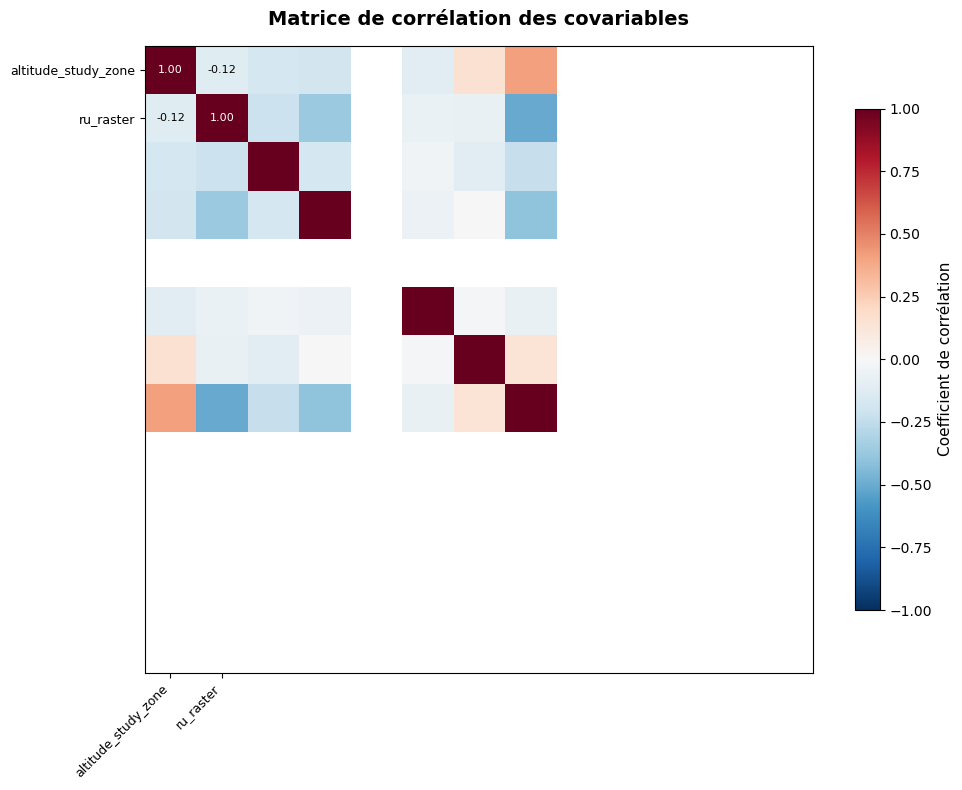


💡 Paires fortement corrélées (|r| > 0.8) :


In [98]:
# Correlation matrix of environmental variables
fig, ax = plt.subplots(figsize=(10, 8))

# Calcul de la matrice de corrélation (en ignorant les NaN)
X_numpy = X_tensor.numpy()
valid_mask = ~np.isnan(X_numpy).any(axis=1)
corr_matrix = np.corrcoef(X_numpy[valid_mask].T)

# Noms de variables nettoyés
var_names = [
    f.replace('data/cov/rasters/', '')
     .replace('alt\\', '').replace('cwb/', '').replace('ru\\', '')
     .replace('.tif', '')
    for f in raster_files
]

# Heatmap
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Coefficient de corrélation', fontsize=11)

# Annotations des valeurs dans chaque cellule
for i in range(len(var_names)):
    for j in range(len(var_names)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(corr_matrix[i, j]) < 0.7 else 'white')

ax.set_xticks(range(len(var_names)))
ax.set_yticks(range(len(var_names)))
ax.set_xticklabels(var_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(var_names, fontsize=9)
ax.set_title('Matrice de corrélation des covariables', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Paires fortement corrélées
print("\n💡 Paires fortement corrélées (|r| > 0.8) :")
for i in range(len(var_names)):
    for j in range(i+1, len(var_names)):
        if abs(corr_matrix[i, j]) > 0.8:
            print(f"   {var_names[i]} ↔ {var_names[j]} : r = {corr_matrix[i, j]:.2f}")

## 8. SPATIAL SPLIT FOR TEST/TRAINING

In [99]:
# Block K-Fold
NUM_CV_BLOCKS   = (5, 5)  # grille de blocs 5×5 sur la zone
N_SPLITS        = 5       #  3folds → ~80% train / 20% val par fold
GLOBAL_SEED     = 42

# Coordonnées lon/lat des cellules observées
obs_indices = np.where(observed_mask.numpy())[0]
grid_wgs84  = grid.to_crs("EPSG:4326")
coords_obs  = np.array([
    (grid_wgs84.geometry.iloc[i].centroid.x,
     grid_wgs84.geometry.iloc[i].centroid.y)
    for i in obs_indices
])
X_lat_long = torch.tensor(coords_obs, dtype=torch.float32)

print(f"📍 Cellules observées : {len(obs_indices)}")
print(f"   Shape X_lat_long  : {X_lat_long.shape}")

📍 Cellules observées : 197
   Shape X_lat_long  : torch.Size([197, 2])


In [100]:
# Tenseurs sur cellules observées uniquement
X_obs = X_tensor[observed_mask]
y_obs = y_tensor[observed_mask]

# Block K-Fold spatial
kfold = vd.BlockKFold(
    shape        = NUM_CV_BLOCKS,
    n_splits     = N_SPLITS,
    shuffle      = True,
    balance      = True,
    random_state = GLOBAL_SEED
).split(X_lat_long.numpy())

# Construction des datasets par fold
x_trains, y_trains = [], []
x_vals,   y_vals   = [], []

for ind_train, ind_val in kfold:
    x_trains.append(X_obs[ind_train])
    y_trains.append(y_obs[ind_train])
    x_vals.append(X_obs[ind_val])
    y_vals.append(y_obs[ind_val])

print(f"✅ {N_SPLITS} folds créés :")
for i in range(N_SPLITS):
    n_train = len(x_trains[i])
    n_val   = len(x_vals[i])
    n_pos_t = y_trains[i].sum().item()
    n_pos_v = y_vals[i].sum().item()
    print(f"   Fold {i+1} — Train : {n_train} ({n_pos_t:.0f} présences) "
          f"| Val : {n_val} ({n_pos_v:.0f} présences)")

✅ 5 folds créés :
   Fold 1 — Train : 169 (83 présences) | Val : 28 (12 présences)
   Fold 2 — Train : 154 (69 présences) | Val : 43 (26 présences)
   Fold 3 — Train : 158 (79 présences) | Val : 39 (16 présences)
   Fold 4 — Train : 155 (69 présences) | Val : 42 (26 présences)
   Fold 5 — Train : 152 (80 présences) | Val : 45 (15 présences)


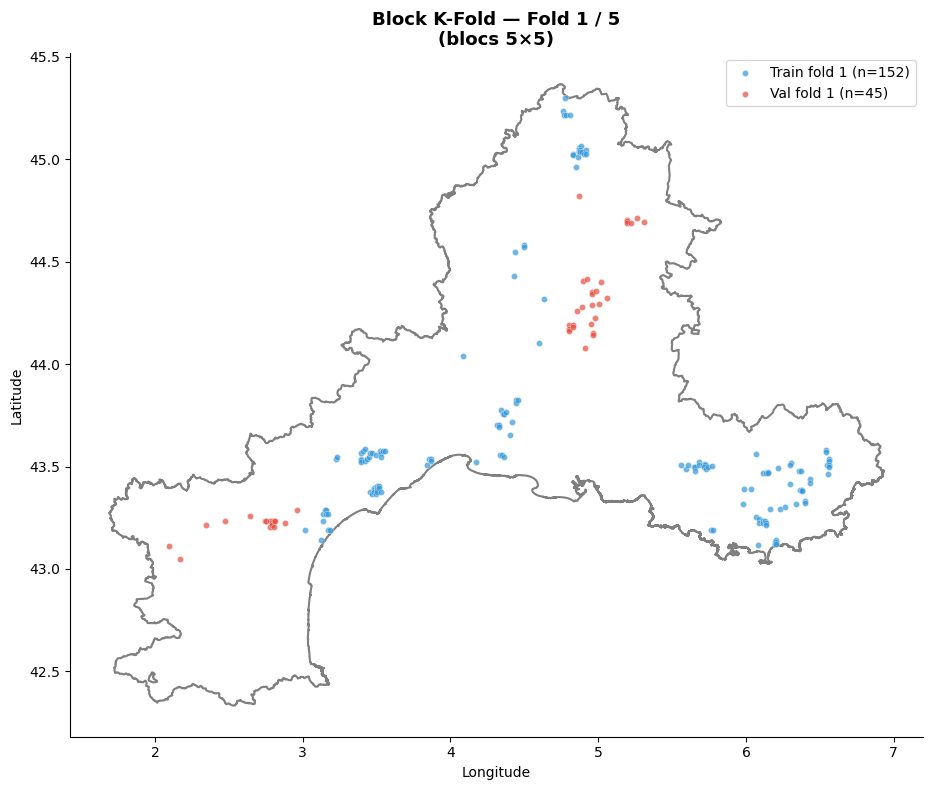

In [101]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
study_zone_wgs = study_zone.to_crs("EPSG:4326")
study_zone_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)

# Recréer le kfold pour visualisation
kfold_viz = vd.BlockKFold(
    shape        = NUM_CV_BLOCKS,
    n_splits     = N_SPLITS,
    shuffle      = True,
    balance      = False,
    random_state = GLOBAL_SEED
).split(X_lat_long.numpy())

for fold_idx, (ind_train, ind_val) in enumerate(kfold_viz):
    if fold_idx == 0:
        train_coords_f1 = coords_obs[ind_train]
        val_coords_f1   = coords_obs[ind_val]
        break

ax.scatter(train_coords_f1[:, 0], train_coords_f1[:, 1],
           c='#3498db', s=20, alpha=0.7, label=f'Train fold 1 (n={len(train_coords_f1)})',
           edgecolor='white', linewidth=0.3)
ax.scatter(val_coords_f1[:, 0], val_coords_f1[:, 1],
           c='#e74c3c', s=20, alpha=0.7, label=f'Val fold 1 (n={len(val_coords_f1)})',
           edgecolor='white', linewidth=0.3)

ax.set_title(f'Block K-Fold — Fold 1 / {N_SPLITS}\n(blocs {NUM_CV_BLOCKS[0]}×{NUM_CV_BLOCKS[1]})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 9. MODEL TRAINING

# 9.1 MODEL CONFIGURATION AND TRAINING

In [102]:
# Additional imports for training
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

# Training configuration
class Args:
    def __init__(self):
        self.learning_rate = 0.001
        self.epoch         = 75
        self.hidden_nbr    = 2
        self.weight_decay  = 1e-3
        self.batch_size    = 16

args = Args()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device : {device}")

# Paramètres du modèle
input_size  = X_obs.shape[1]  # nb covariables — X_obs existe toujours
output_size = 1
hidden_size = 64

# Nombre de colonnes continues (tout sauf les one-hot RU)
n_onehot     = len(ru_classes)  # 6
n_continuous = X_obs.shape[1] - n_onehot

print(f"   Colonnes continues : {n_continuous}")
print(f"   Colonnes one-hot   : {n_onehot}")

print(f"\n🧠 Architecture du modèle :")
print(f"   Input  : {input_size} covariables")
print(f"   Hidden : {hidden_size} × {args.hidden_nbr} couches")
print(f"   Output : {output_size} (iG-APEX)")

print(f"\n⚙️  Configuration d'entraînement :")
print(f"   Learning rate : {args.learning_rate}")
print(f"   Epochs        : {args.epoch}")
print(f"   Weight decay  : {args.weight_decay}")
print(f"   Batch size    : {args.batch_size}")

🖥️  Device : cuda
   Colonnes continues : 7
   Colonnes one-hot   : 6

🧠 Architecture du modèle :
   Input  : 13 covariables
   Hidden : 64 × 2 couches
   Output : 1 (iG-APEX)

⚙️  Configuration d'entraînement :
   Learning rate : 0.001
   Epochs        : 75
   Weight decay  : 0.001
   Batch size    : 16


9.2 TRAINING LOOPS WITH VALIDATION RMSE

In [103]:
import torch.nn as nn

class mlp_model(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_nbr, dropout_p=0.2):
        super(mlp_model, self).__init__()
        self.dropout_p = dropout_p
        layers = []

        layers += [
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_p)
        ]
        for _ in range(hidden_nbr - 1):
            layers += [
                nn.Linear(hidden_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(p=dropout_p)
            ]
        layers.append(nn.Linear(hidden_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

    def mc_forward(self, x, n_samples=50):
        """Garde le dropout actif pour l'inférence MC."""
        self.train()  # dropout actif
        with torch.no_grad():
            preds = torch.stack([
                torch.sigmoid(self.network(x)).squeeze()
                for _ in range(n_samples)
            ], dim=0)  # (n_samples, n_cells)
        return preds

In [104]:
def predict_with_uncertainty(model, X_tensor, device, n_samples=50):
    """
    Retourne moyenne et incertitude (std) des prédictions MC-Dropout.
    """
    X = X_tensor.to(device)
    preds = model.mc_forward(X, n_samples=n_samples)  # (n_samples, n_cells)

    mean_pred = preds.mean(dim=0).cpu()   # prédiction moyenne
    std_pred  = preds.std(dim=0).cpu()    # incertitude

    return mean_pred, std_pred

In [105]:
def train_model(X_train, y_train, X_val, y_val, args, hidden_size=128, device="cpu"):
    """
    Entraînement d'un MLP pour la régression de l'iG-APEX.

    Returns:
        dict : modèle, historique des pertes, meilleur val_loss
    """
    # DataLoader
    train_dataset = TensorDataset(X_train, y_train)
    train_loader  = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)

    # Modèle, loss, optimizer
    input_size  = X_train.shape[1]
    model       = mlp_model(input_size, hidden_size, args.hidden_nbr).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer   = optim.Adam(
        model.parameters(),
        lr=args.learning_rate,
        weight_decay=args.weight_decay
    )

    # Historique
    train_losses = []
    val_losses   = []
    best_val_loss    = float('inf')
    best_model_state = None

    print("🚀 Entraînement...")
    print("=" * 60)

    for epoch in tqdm(range(args.epoch), desc="Training"):

        # Phase train
        model.train()
        total_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss    = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Phase validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val.to(device)).squeeze()
            val_loss    = criterion(val_outputs, y_val.to(device)).item()
        val_losses.append(val_loss)

        # Log tous les 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            val_rmse = np.sqrt(val_loss)
            print(f"   Epoch {epoch+1:3d} | Train bce: {avg_train_loss:.4f} | "
                  f"Val bce: {val_loss:.4f} | Val RMSE: {val_rmse:.4f}")

        # Sauvegarde du meilleur modèle
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    # Rechargement du meilleur état
    if best_model_state is None:
        print("⚠️  Aucun meilleur modèle sauvegardé — val_loss était NaN/inf à chaque epoch")
        print("   Vérification des tenseurs d'entrée :")
        print(f"   X_train NaN : {torch.isnan(X_train).sum().item()}")
        print(f"   y_train NaN : {torch.isnan(y_train).sum().item()}")
        print(f"   y_train inf : {torch.isinf(y_train).sum().item()}")
        return None
    
    model.load_state_dict(best_model_state)

    print("=" * 60)
    print(f"✅ Entraînement terminé ! Meilleur Val bce : {best_val_loss:.4f} "
          f"| RMSE : {np.sqrt(best_val_loss):.4f}")

    return {
        "model"       : model,
        "train_losses": train_losses,
        "val_losses"  : val_losses,
        "best_val_loss": best_val_loss
    }

In [106]:
all_results = []

for fold_idx in range(N_SPLITS):
    print(f"\n{'='*60}")
    print(f"🔁 FOLD {fold_idx + 1} / {N_SPLITS}")
    print(f"{'='*60}")

    # Preprocessing du fold
    X_train_raw = x_trains[fold_idx]
    X_val_raw   = x_vals[fold_idx]
    y_train_f   = y_trains[fold_idx]
    y_val_f     = y_vals[fold_idx]

    # Suppression NaN
    train_nan_mask = torch.isnan(X_train_raw).any(dim=1)
    val_nan_mask   = torch.isnan(X_val_raw).any(dim=1)
    X_train_clean  = X_train_raw[~train_nan_mask]
    y_train_clean  = y_train_f[~train_nan_mask]
    X_val_clean    = X_val_raw[~val_nan_mask]
    y_val_clean    = y_val_f[~val_nan_mask]

    # Normalisation (fit sur train uniquement)
    scaler_fold = StandardScaler()
    X_train_cont_scaled = scaler_fold.fit_transform(X_train_clean[:, :n_continuous].numpy())
    X_val_cont_scaled   = scaler_fold.transform(X_val_clean[:, :n_continuous].numpy())

    X_train_tensor_f = torch.tensor(
        np.concatenate([X_train_cont_scaled, X_train_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    # Entraînement
    fold_results = train_model(
        X_train     = X_train_tensor_f,
        y_train     = y_train_clean,
        X_val       = X_val_tensor_f,
        y_val       = y_val_clean,
        args        = args,
        hidden_size = hidden_size,
        device      = device
    )

    if fold_results is not None:
        all_results.append({
            "fold"       : fold_idx + 1,
            "results"    : fold_results,
            "scaler"     : scaler_fold,
            "val_loss"   : fold_results["best_val_loss"]
        })

# Résumé
print(f"\n📊 RÉSUMÉ CROSS-VALIDATION")
print("=" * 60)
val_losses = [r["val_loss"] for r in all_results]
print(f"   BCE par fold : {[f'{v:.4f}' for v in val_losses]}")
print(f"   BCE moyenne  : {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")

# Meilleur fold
best_fold = all_results[np.argmin(val_losses)]
print(f"   Meilleur fold : Fold {best_fold['fold']} (BCE = {best_fold['val_loss']:.4f})")


🔁 FOLD 1 / 5
🚀 Entraînement...


Training:   4%|██▉                                                                      | 3/75 [00:00<00:02, 25.80it/s]

   Epoch   1 | Train bce: 0.7229 | Val bce: 0.6899 | Val RMSE: 0.8306


Training:  17%|████████████▍                                                           | 13/75 [00:00<00:01, 39.73it/s]

   Epoch  10 | Train bce: 0.6548 | Val bce: 0.8530 | Val RMSE: 0.9236


...

   Epoch  50 | Train bce: 0.6245 | Val bce: 0.7570 | Val RMSE: 0.8701


Training:  88%|███████████████████████████████████████████████████████████████▎        | 66/75 [00:01<00:00, 41.15it/s]

   Epoch  60 | Train bce: 0.6450 | Val bce: 0.7712 | Val RMSE: 0.8782
   Epoch  70 | Train bce: 0.6249 | Val bce: 0.7793 | Val RMSE: 0.8828


Training: 100%|████████████████████████████████████████████████████████████████████████| 75/75 [00:01<00:00, 41.88it/s]

✅ Entraînement terminé ! Meilleur Val bce : 0.6960 | RMSE : 0.8342

📊 RÉSUMÉ CROSS-VALIDATION
   BCE par fold : ['0.6899', '0.6928', '0.6936', '0.6986', '0.6960']
   BCE moyenne  : 0.6942 ± 0.0029
   Meilleur fold : Fold 1 (BCE = 0.6899)


9.4 VISUALISE TRAINING PROCESS

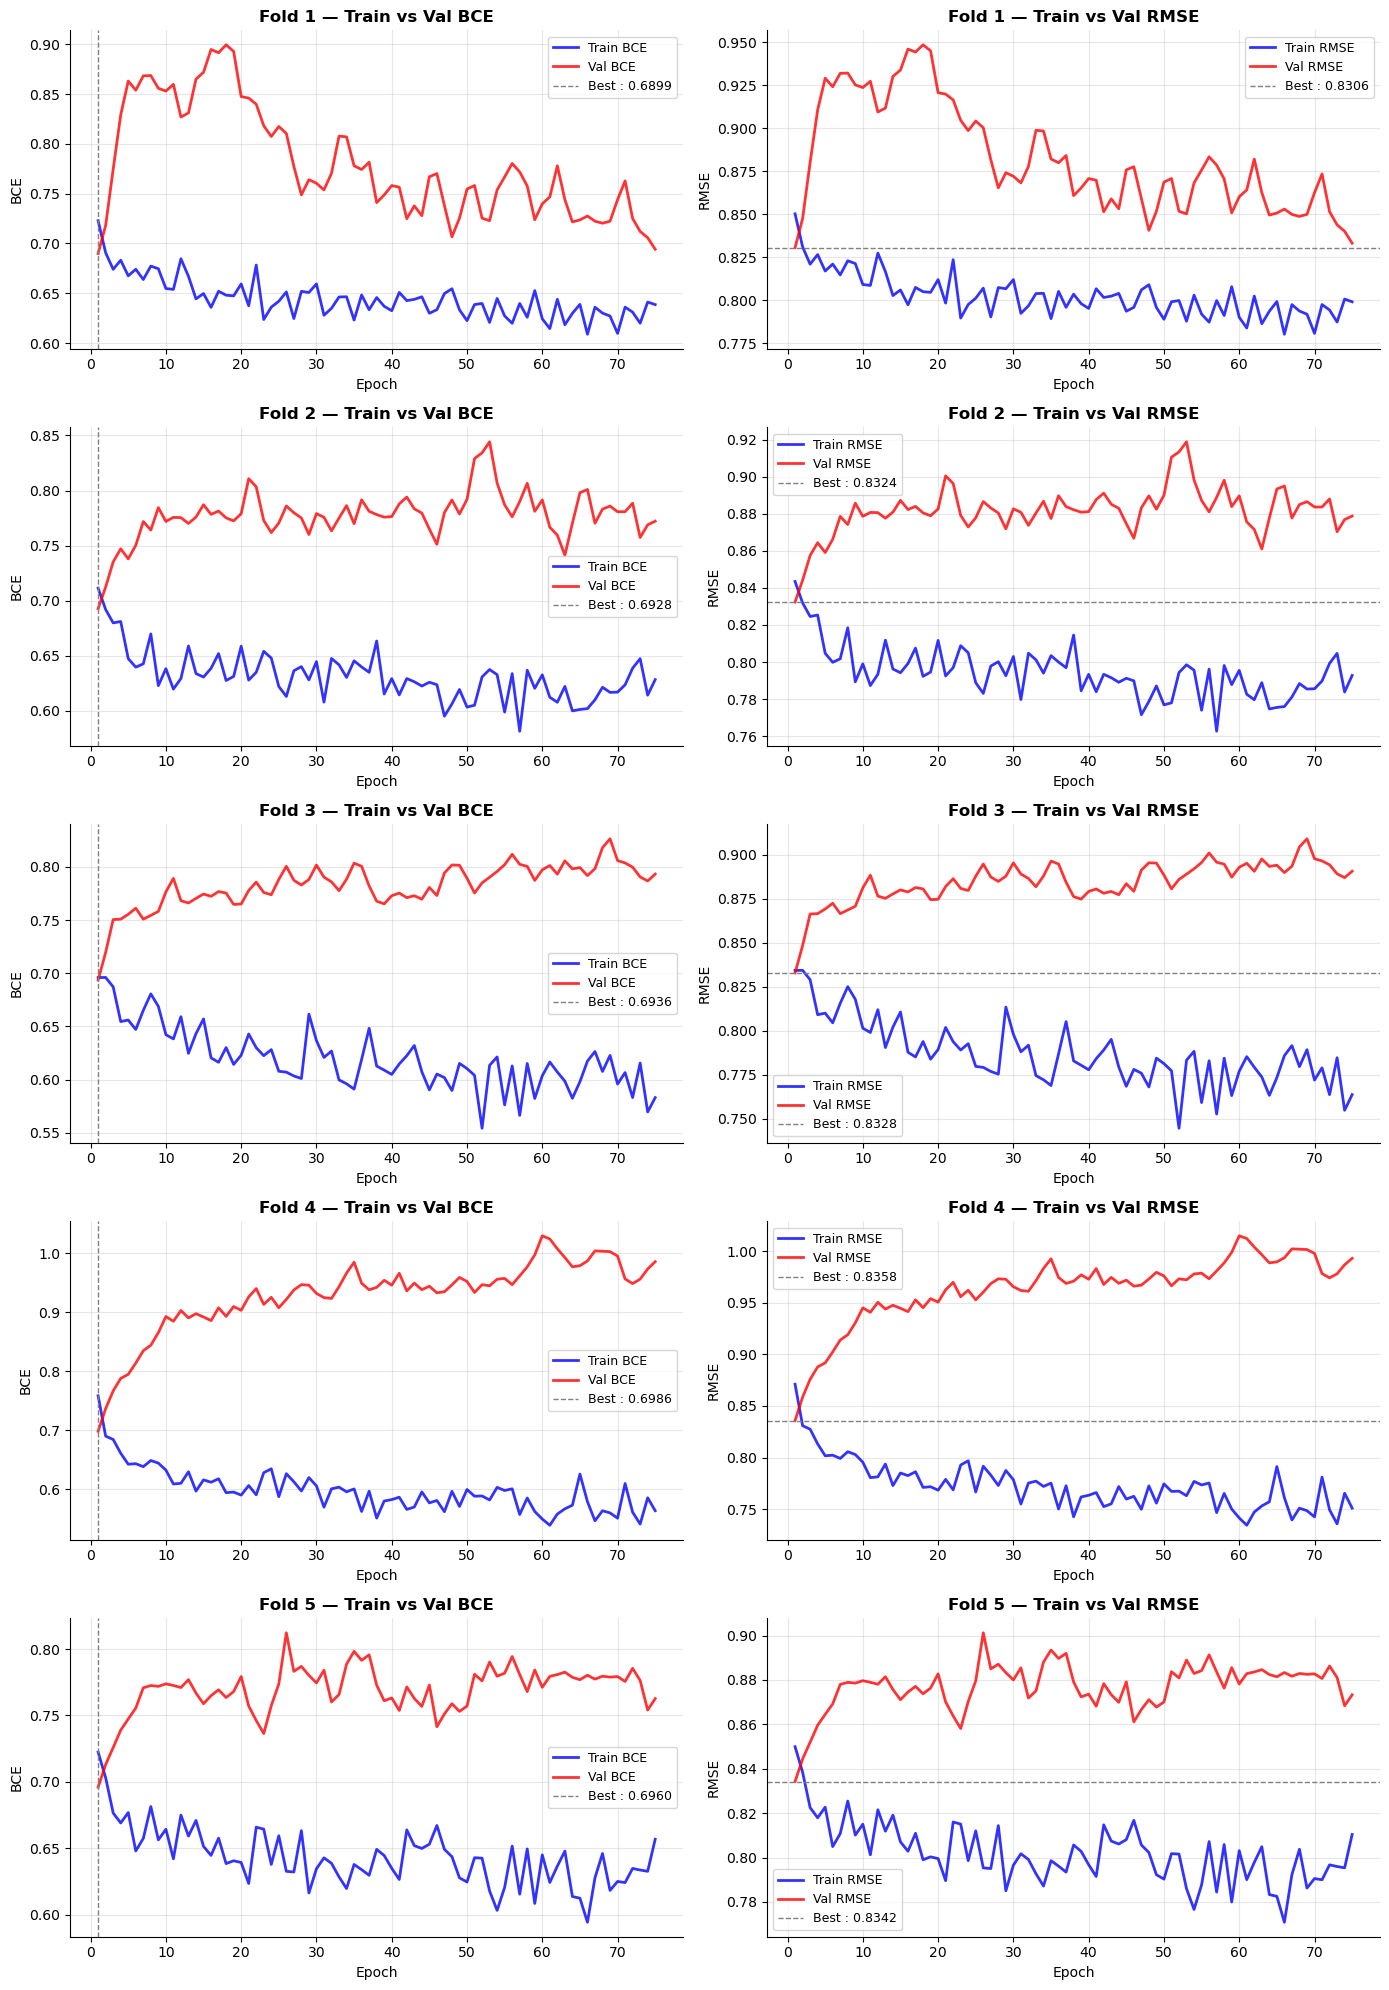


📊 MÉTRIQUES FINALES PAR FOLD
   Fold 1 — BCE : 0.6899 | RMSE : 0.8306
   Fold 2 — BCE : 0.6928 | RMSE : 0.8324
   Fold 3 — BCE : 0.6936 | RMSE : 0.8328
   Fold 4 — BCE : 0.6986 | RMSE : 0.8358
   Fold 5 — BCE : 0.6960 | RMSE : 0.8342


In [107]:
fig, axes = plt.subplots(N_SPLITS, 2, figsize=(14, 4 * N_SPLITS))

for fold_idx, fold_data in enumerate(all_results):
    results_f = fold_data["results"]
    epochs    = range(1, len(results_f['train_losses']) + 1)

    # Courbe BCE
    ax1 = axes[fold_idx, 0]
    ax1.plot(epochs, results_f['train_losses'], 'b-', linewidth=2, label='Train BCE', alpha=0.8)
    ax1.plot(epochs, results_f['val_losses'],   'r-', linewidth=2, label='Val BCE',   alpha=0.8)
    ax1.axvline(x=results_f['val_losses'].index(results_f['best_val_loss']) + 1,
                color='gray', linestyle='--', linewidth=1,
                label=f"Best : {results_f['best_val_loss']:.4f}")
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('BCE')
    ax1.set_title(f'Fold {fold_data["fold"]} — Train vs Val BCE', fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Courbe RMSE
    ax2 = axes[fold_idx, 1]
    train_rmse = [np.sqrt(v) for v in results_f['train_losses']]
    val_rmse   = [np.sqrt(v) for v in results_f['val_losses']]
    ax2.plot(epochs, train_rmse, 'b-', linewidth=2, label='Train RMSE', alpha=0.8)
    ax2.plot(epochs, val_rmse,   'r-', linewidth=2, label='Val RMSE',   alpha=0.8)
    ax2.axhline(y=np.sqrt(results_f['best_val_loss']), color='gray', linestyle='--', linewidth=1,
                label=f"Best : {np.sqrt(results_f['best_val_loss']):.4f}")
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('RMSE')
    ax2.set_title(f'Fold {fold_data["fold"]} — Train vs Val RMSE', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n📊 MÉTRIQUES FINALES PAR FOLD")
print("=" * 50)
for fold_data in all_results:
    r = fold_data["results"]
    print(f"   Fold {fold_data['fold']} — BCE : {r['best_val_loss']:.4f} | RMSE : {np.sqrt(r['best_val_loss']):.4f}")

9.5 EVALUATION

In [108]:
print("📊 ÉVALUATION PAR FOLD")
print("=" * 50)

for fold_data in all_results:
    model_f  = fold_data["results"]["model"]
    fold_idx = fold_data["fold"] - 1

    # Reconstruction X_val normalisé pour ce fold
    X_val_raw   = x_vals[fold_idx]
    y_val_f     = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f    = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    model_f.eval()
    with torch.no_grad():
        val_preds = torch.sigmoid(model_f(X_val_tensor_f.to(device)).squeeze().cpu())
    val_true = y_val_clean

    mse    = nn.MSELoss()(val_preds, val_true).item()
    rmse   = np.sqrt(mse)
    mae    = torch.mean(torch.abs(val_preds - val_true)).item()
    ss_res = torch.sum((val_true - val_preds) ** 2).item()
    ss_tot = torch.sum((val_true - val_true.mean()) ** 2).item()
    r2     = 1 - ss_res / ss_tot

    print(f"\n   Fold {fold_data['fold']} :")
    print(f"   BCE  : {fold_data['val_loss']:.4f}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}")

📊 ÉVALUATION PAR FOLD

   Fold 1 :
   BCE  : 0.6899
   RMSE : 0.4984
   MAE  : 0.4981
   R²   : -0.0142

   Fold 2 :
   BCE  : 0.6928
   RMSE : 0.5000
   MAE  : 0.4988
   R²   : -0.0458

   Fold 3 :
   BCE  : 0.6936
   RMSE : 0.5002
   MAE  : 0.4994
   R²   : -0.0341

   Fold 4 :
   BCE  : 0.6986
   RMSE : 0.5026
   MAE  : 0.5017
   R²   : -0.0713

   Fold 5 :
   BCE  : 0.6960
   RMSE : 0.5014
   MAE  : 0.5013
   R²   : -0.1313


In [109]:
# Corrélations sur le meilleur fold — toutes les covariables continues
best_fold_idx = best_fold["fold"] - 1
y_train_best  = y_trains[best_fold_idx]
X_train_best  = x_trains[best_fold_idx]

print(f"📊 Corrélations covariables → iG-APEX binaire (train fold {best_fold['fold']}) :")
var_names_clean = [
    f.replace('data/cov/rasters/', '')
     .replace('alt/', '').replace('cwb/', '').replace('ru/', '')
     .replace('.tif', '')
    for f in raster_files[:n_continuous]  # toutes les continues : alt + cwb*N
]
for i, name in enumerate(var_names_clean):
    x_col = X_train_best[:, i]
    mask  = ~torch.isnan(x_col)
    corr  = np.corrcoef(x_col[mask].numpy(), y_train_best[mask].numpy())[0, 1]
    print(f"   {name:40s} r = {corr:.3f}")

# Corrélations RU (one-hot) → iG-APEX binaire
print(f"\n📊 Corrélations RU (one-hot) → iG-APEX binaire (train fold {best_fold['fold']}) :")
for j, cls in enumerate(ru_classes):
    x_col = X_train_best[:, n_continuous + j]
    mask  = ~torch.isnan(x_col)
    corr  = np.corrcoef(x_col[mask].numpy(), y_train_best[mask].numpy())[0, 1]
    label = f"RU classe {cls}"
    if cls == 9:
        label += " (non-sol)"
    elif cls == 1:
        label += " (< 50mm)"
    elif cls == 2:
        label += " (50-100mm)"
    elif cls == 3:
        label += " (100-150mm)"
    elif cls == 4:
        label += " (150-200mm)"
    elif cls == 5:
        label += " (>= 200mm)"
    print(f"   {label:35s} r = {corr:.3f}")

📊 Corrélations covariables → iG-APEX binaire (train fold 1) :
   alt\altitude_study_zone                  r = -0.059
   ru\ru_raster                             r = -0.050

📊 Corrélations RU (one-hot) → iG-APEX binaire (train fold 1) :
   RU classe 1 (< 50mm)                r = -0.026
   RU classe 2 (50-100mm)              r = nan
   RU classe 3 (100-150mm)             r = nan
   RU classe 4 (150-200mm)             r = nan
   RU classe 5 (>= 200mm)              r = nan
   RU classe 9 (non-sol)               r = nan


## 10. GENERATE IG-APEX MAP

In [110]:
# Utiliser le modèle et scaler du meilleur fold
best_model  = best_fold["results"]["model"]
best_scaler = best_fold["scaler"]

# Reconstruction X_full_tensor avec le scaler du meilleur fold
full_nan_mask = (
    torch.isnan(X_tensor).any(dim=1) |
    torch.tensor(ru_values == 9, dtype=torch.bool) |
    highalt_mask
)
X_full_clean  = X_tensor[~full_nan_mask]
valid_indices = torch.where(~full_nan_mask)[0]

X_full_cont_scaled = best_scaler.transform(X_full_clean[:, :n_continuous].numpy())
X_full_scaled      = np.concatenate(
    [X_full_cont_scaled, X_full_clean[:, n_continuous:].numpy()], axis=1
)
X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32)

print(f"✅ X_full_tensor prêt pour la carte : {X_full_tensor.shape}")

✅ X_full_tensor prêt pour la carte : torch.Size([197, 13])


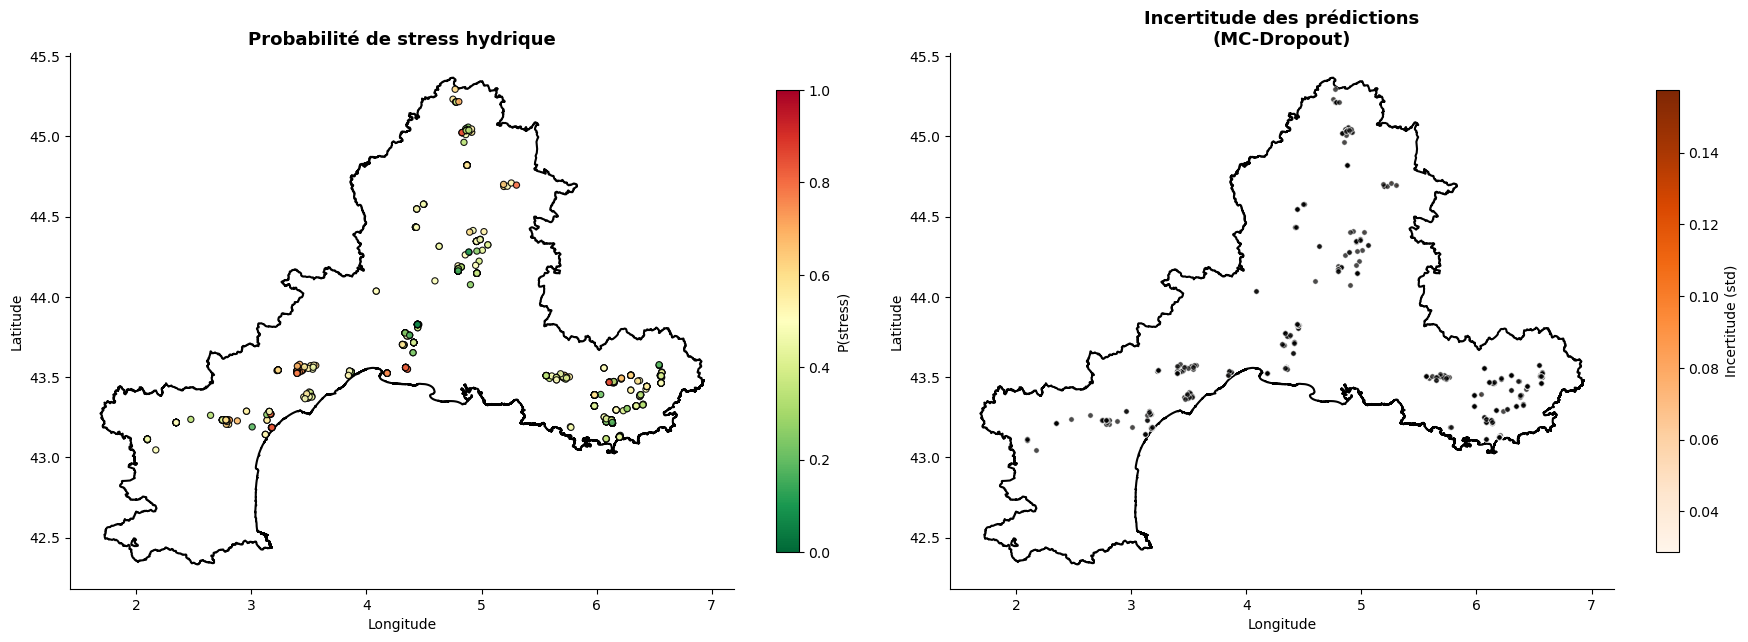


📊 Statistiques des prédictions MC-Dropout (100 samples) :
   Probabilité moyenne  : 0.481
   Incertitude moyenne  : 0.053
   Incertitude max      : 0.157


In [111]:
# Prédiction MC sur toutes les cellules valides
mean_preds, std_preds = predict_with_uncertainty(
    model     = best_fold["results"]["model"],
    X_tensor  = X_full_tensor,
    device    = device,
    n_samples = 100
)

# Reconstruction sur toute la grille
# Ordre correct
pred_mean_full = torch.full((num_cells,), float('nan'))
pred_std_full  = torch.full((num_cells,), float('nan'))
pred_mean_full[valid_indices] = mean_preds          # 1. assigner
pred_std_full[valid_indices]  = std_preds
pred_mean_full[valid_indices] = 1 - pred_mean_full[valid_indices]  # 2. inverser après

# Carte double — prédiction + incertitude
grid_pred = grid_wgs84.copy()
grid_pred['ig_apex_pred'] = pred_mean_full.numpy()
grid_pred['uncertainty']  = pred_std_full.numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Carte prédiction
ax1 = axes[0]
grid_pred.dropna(subset=['ig_apex_pred']).plot(
    ax=ax1, column='ig_apex_pred', cmap='RdYlGn_r',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'P(stress)', 'shrink': 0.6},
    vmin=0, vmax=1,
    aspect=None
)
study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5)

# Observations superposées
data_zone_wgs.plot(
    ax=ax1, column='ig_apex', cmap='RdYlGn_r',
    markersize=20, edgecolor='black', linewidth=0.8,
    alpha=0.9, legend=False, vmin=0, vmax=1
)
ax1.set_title('Probabilité de stress hydrique', fontsize=13, fontweight='bold')

# Carte incertitude
ax2 = axes[1]
grid_pred.dropna(subset=['uncertainty']).plot(
    ax=ax2, column='uncertainty', cmap='Oranges',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Incertitude (std)', 'shrink': 0.6},
    aspect=None
)
study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5)

# Observations superposées (couleur fixe pour ne pas confondre avec l'incertitude)
data_zone_wgs.plot(
    ax=ax2, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax2.set_title('Incertitude des prédictions\n(MC-Dropout)', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n📊 Statistiques des prédictions MC-Dropout ({100} samples) :")
valid_mean = pred_mean_full[~torch.isnan(pred_mean_full)]
valid_std  = pred_std_full[~torch.isnan(pred_std_full)]
print(f"   Probabilité moyenne  : {valid_mean.mean():.3f}")
print(f"   Incertitude moyenne  : {valid_std.mean():.3f}")
print(f"   Incertitude max      : {valid_std.max():.3f}")